In [ ]:
# Importer les bibliothèques utiles
import pandas as pd
import numpy as np

#Importations utiles pour la visualisation
#import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
#/content/drive/MyDrive/ColabNotebooks/detection_anomalie_transaction_bancaire/creditcard.csv
df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/detection_anomalie_transaction_bancaire/creditcard.csv')
# Cellule 3 - Aperçu des premières lignes
print("Aperçu du dataset :")
display(df.head())

Aperçu du dataset :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Statistiques globales
print("Statistiques descriptives globales :")
display(df.describe())

Statistiques descriptives globales :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# Types de données, nombre de valeurs non nulles
print("Informations sur les colonnes :")
df.info()

Informations sur les colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 n

In [ ]:
# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())
doublons=df.duplicated()
# Vérifie combien de lignes sont strictement dupliquées
nb_doublons = doublons.sum()
print(f"Nombre de doublons détectés : {nb_doublons}")

df[df.duplicated()]['Class'].value_counts()
#Nombre de doublon Fraude et Non Fraude
#Ce qu’il faut faire dans ce cas, car il se peut que le modèle “triche” en apprenant 19 fois la même fraude

# Supprimer tous les doublons (même dans les fraudes)
df = df.drop_duplicates()

# Confirmer le nouveau nombre de lignes
print("Taille après suppression des doublons :", df.shape)
#Taille après suppression des doublons : (283726, 32)
#284807 au total donc très logique
print("Nombre de doublons restants :", df.duplicated().sum())


Valeurs manquantes par colonne :
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Nombre de doublons détectés : 1081
Taille après suppression des doublons : (283726, 31)
Nombre de doublons restants : 0


In [ ]:
# Répartition de la variable cible
print("\nRépartition des classes (fraude vs non-fraude) :")
print(df['Class'].value_counts(normalize=True))  # % de fraude
print("\nDétail brut :")
print(df['Class'].value_counts())  # nombre de cas


#Ce type de déséquilibre est très fréquent en détection de fraude :
#Il y a naturellement beaucoup plus de transactions normales que frauduleuses.

#Dans notre cas, il faut:
  #-Rééquilibrer les classes à l’entraînement

  #-Utiliser des métriques adaptées pour l’évaluation



Répartition des classes (fraude vs non-fraude) :
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

Détail brut :
Class
0    283253
1       473
Name: count, dtype: int64


In [ ]:
# Moyenne et écart-type personnalisés
print("\nMoyenne et écart-type des colonnes numériques :")
means = df.mean()
stds = df.std()
for col in df.columns[:-1]:  # on exclut 'Class'
    print(f"{col:<8} ➜ Moyenne: {means[col]:.4f} | Écart-type: {stds[col]:.4f}")



Moyenne et écart-type des colonnes numériques :
Time     ➜ Moyenne: 94813.8596 | Écart-type: 47488.1460
V1       ➜ Moyenne: 0.0000 | Écart-type: 1.9587
V2       ➜ Moyenne: 0.0000 | Écart-type: 1.6513
V3       ➜ Moyenne: -0.0000 | Écart-type: 1.5163
V4       ➜ Moyenne: 0.0000 | Écart-type: 1.4159
V5       ➜ Moyenne: 0.0000 | Écart-type: 1.3802
V6       ➜ Moyenne: 0.0000 | Écart-type: 1.3323
V7       ➜ Moyenne: -0.0000 | Écart-type: 1.2371
V8       ➜ Moyenne: 0.0000 | Écart-type: 1.1944
V9       ➜ Moyenne: -0.0000 | Écart-type: 1.0986
V10      ➜ Moyenne: 0.0000 | Écart-type: 1.0888
V11      ➜ Moyenne: 0.0000 | Écart-type: 1.0207
V12      ➜ Moyenne: -0.0000 | Écart-type: 0.9992
V13      ➜ Moyenne: 0.0000 | Écart-type: 0.9953
V14      ➜ Moyenne: 0.0000 | Écart-type: 0.9586
V15      ➜ Moyenne: 0.0000 | Écart-type: 0.9153
V16      ➜ Moyenne: 0.0000 | Écart-type: 0.8763
V17      ➜ Moyenne: -0.0000 | Écart-type: 0.8493
V18      ➜ Moyenne: 0.0000 | Écart-type: 0.8382
V19      ➜ Moyenne: 0.0000

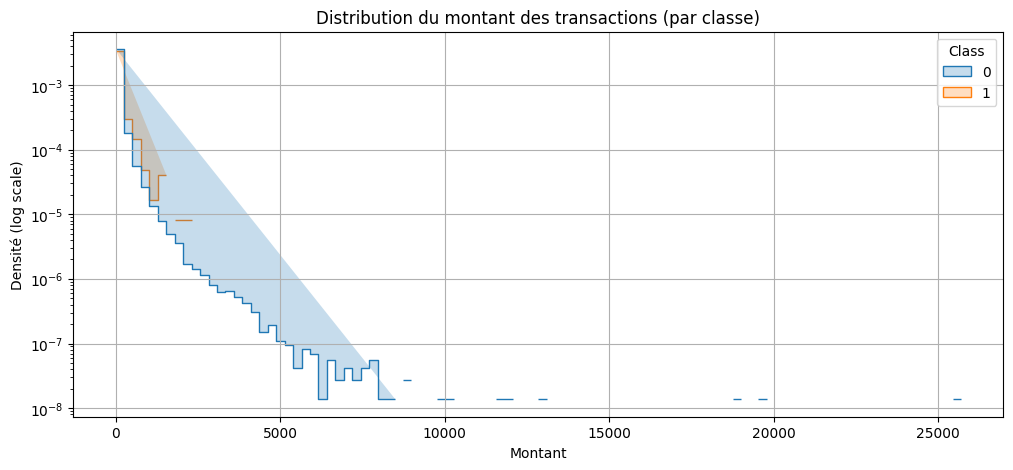

In [ ]:
# Histogramme de la variable 'Amount' selon la classe
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Amount', hue='Class', bins=100, log_scale=(False, True), element="step", stat="density", common_norm=False)
plt.title("Distribution du montant des transactions (par classe)")
plt.xlabel("Montant")
plt.ylabel("Densité (log scale)")
plt.grid(True)
plt.show()

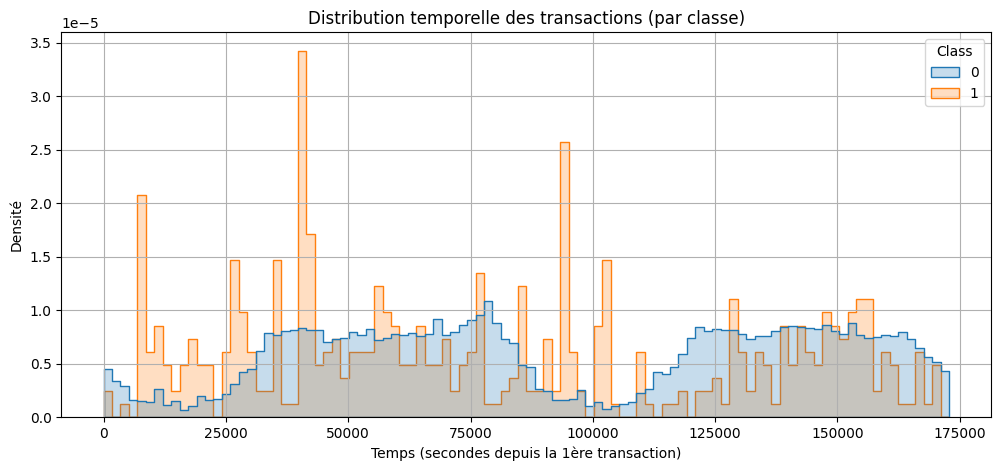

In [ ]:
#  Distribution de la variable 'Time'
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Time', hue='Class', bins=100, element="step", stat="density", common_norm=False)
plt.title("Distribution temporelle des transactions (par classe)")
plt.xlabel("Temps (secondes depuis la 1ère transaction)")
plt.ylabel("Densité")
plt.grid(True)
plt.show()

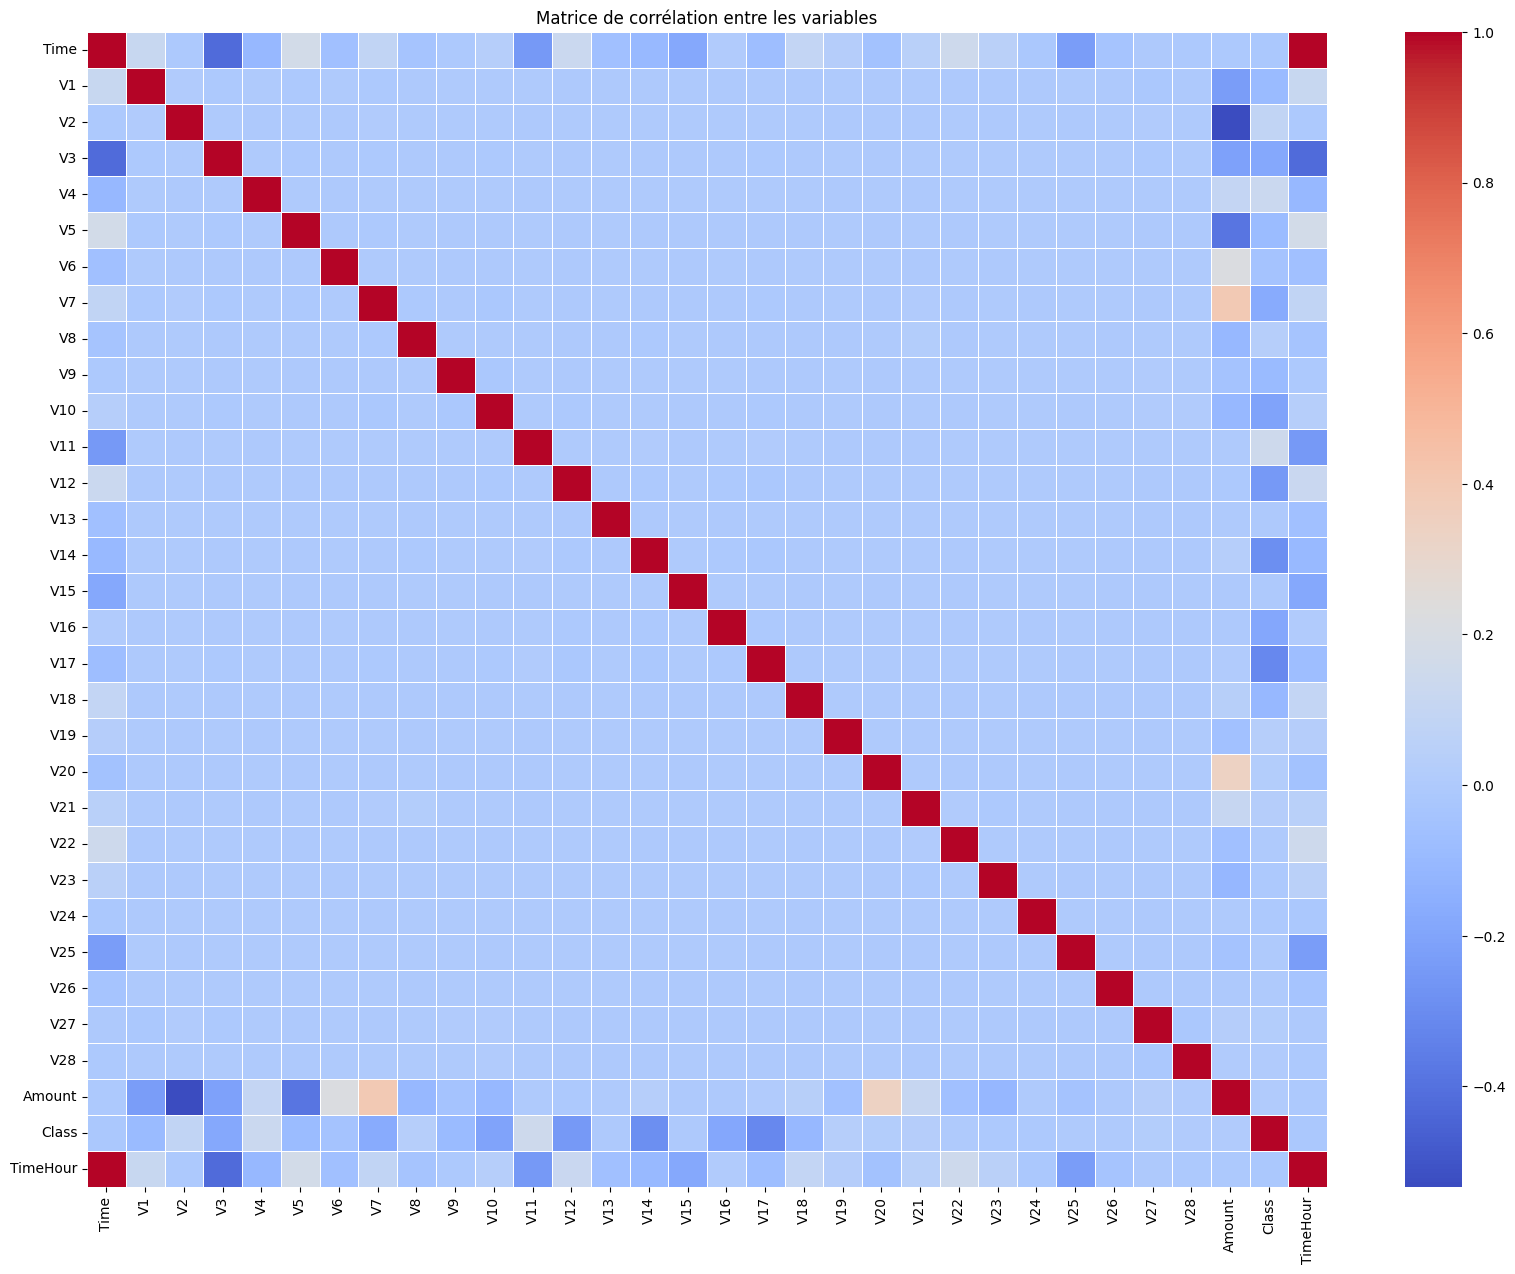

In [ ]:
# Matrice de corrélation
plt.figure(figsize=(20, 15))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation entre les variables")
plt.show()

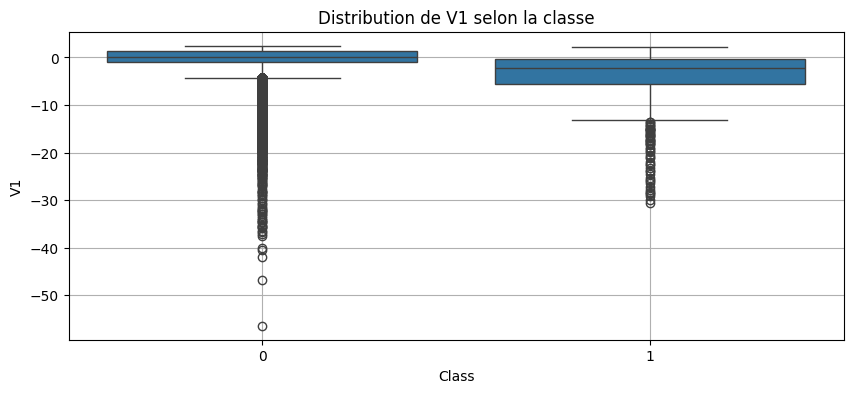

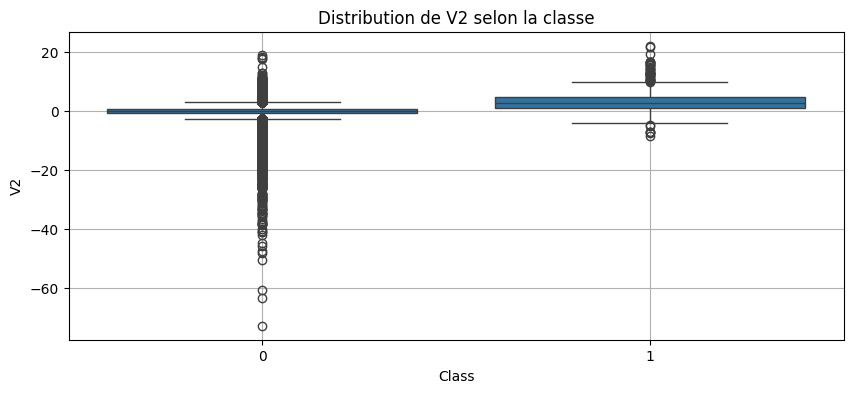

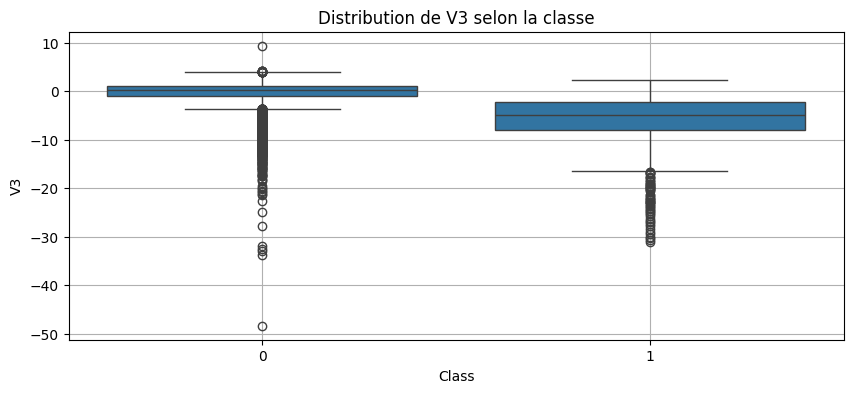

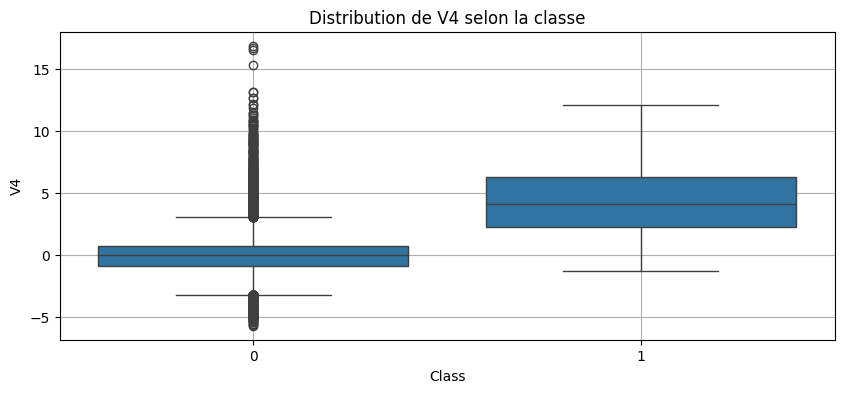

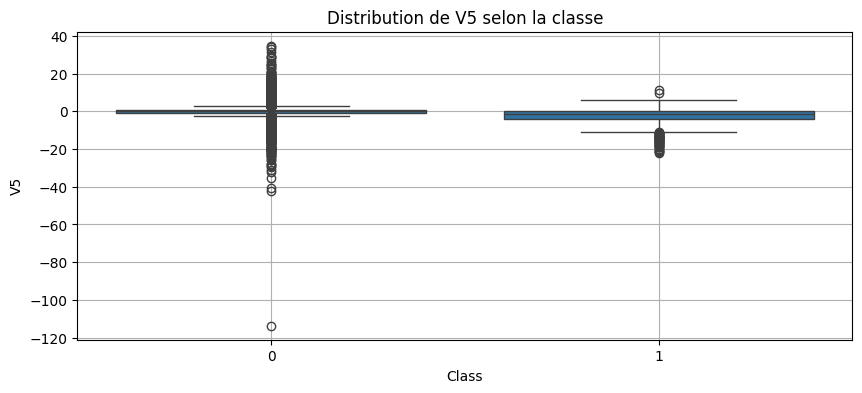

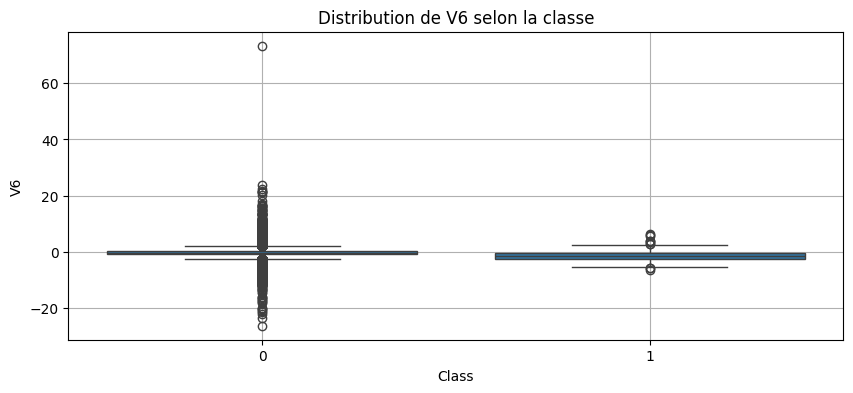

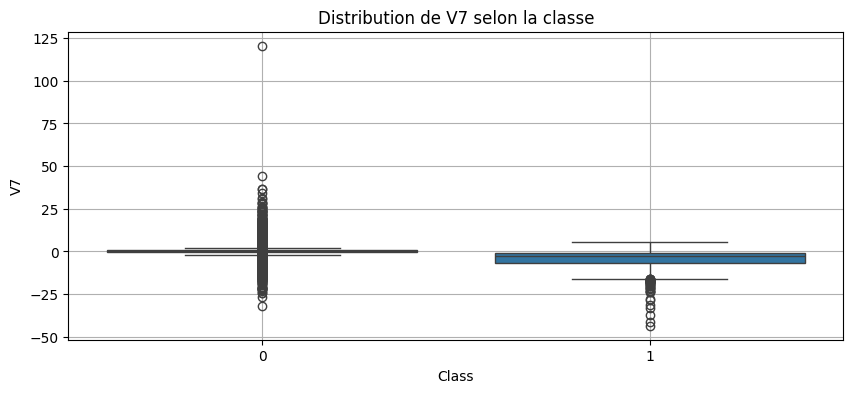

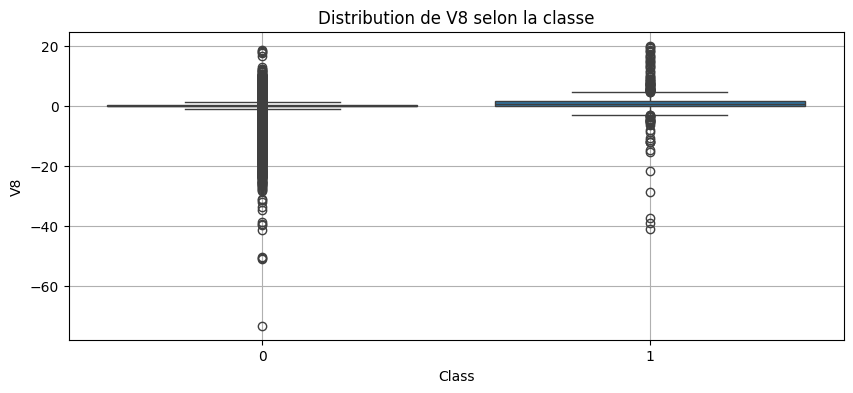

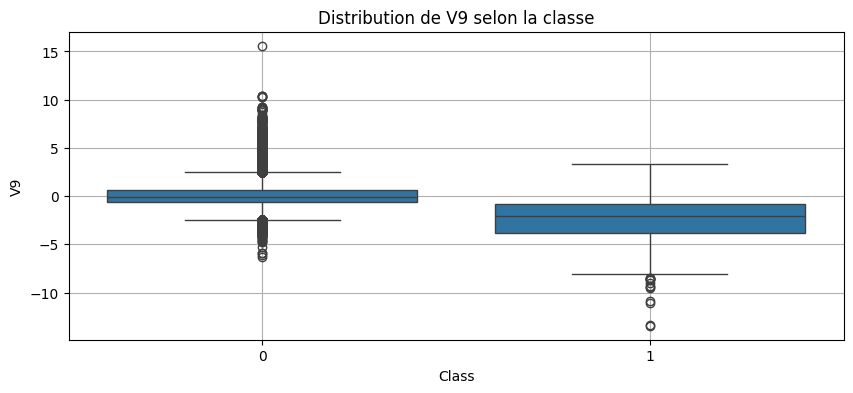

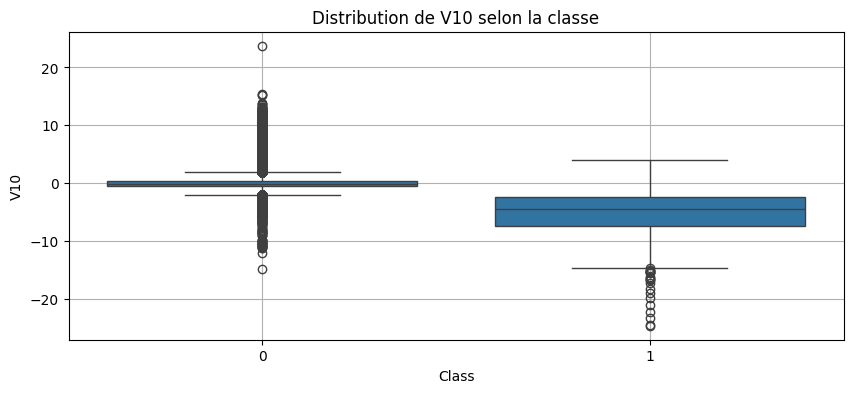

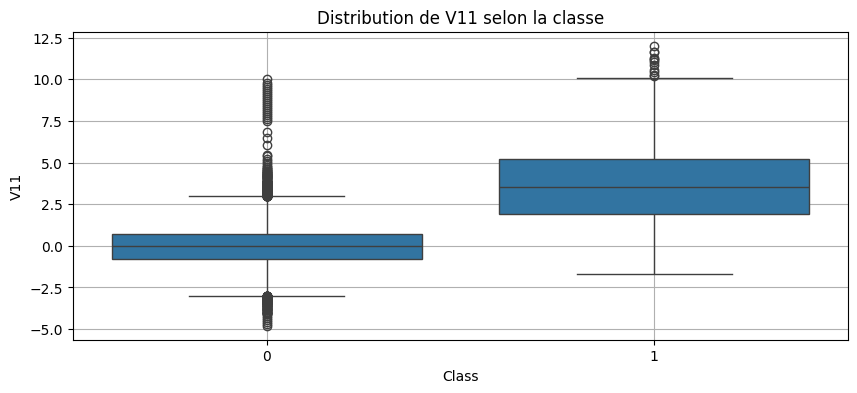

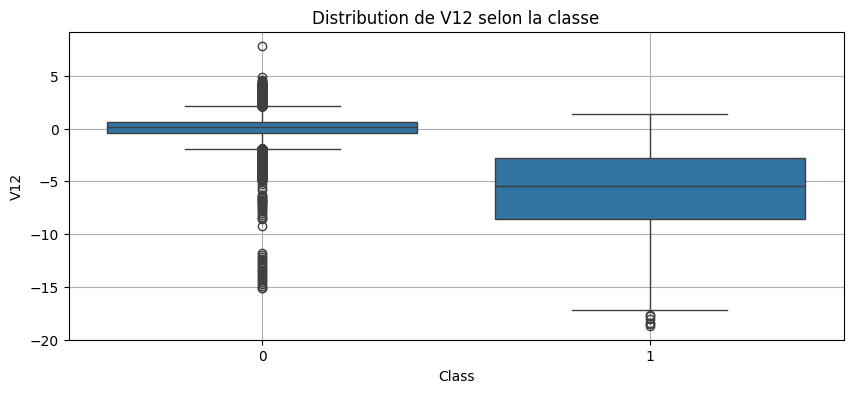

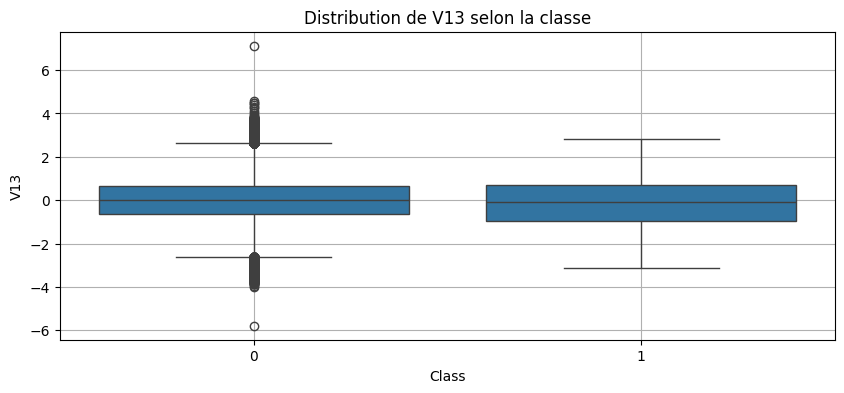

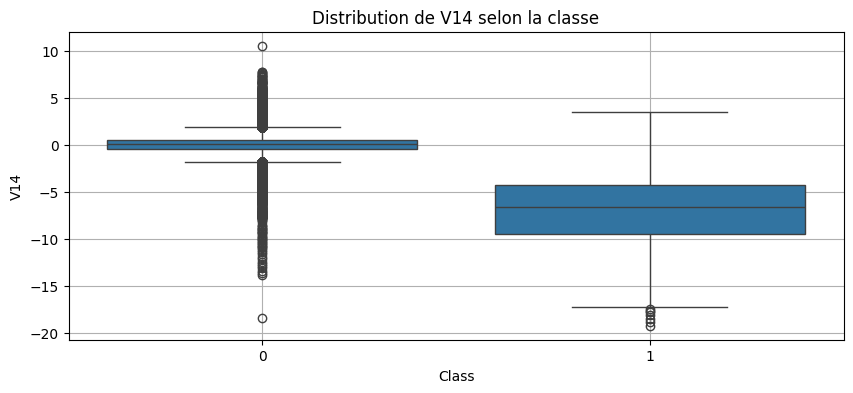

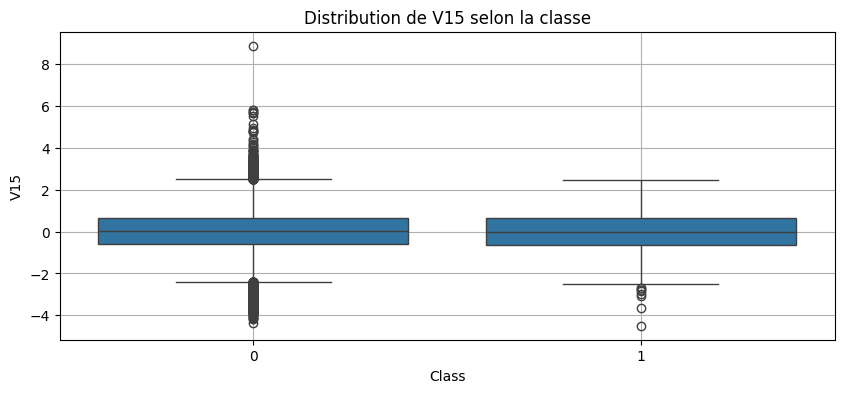

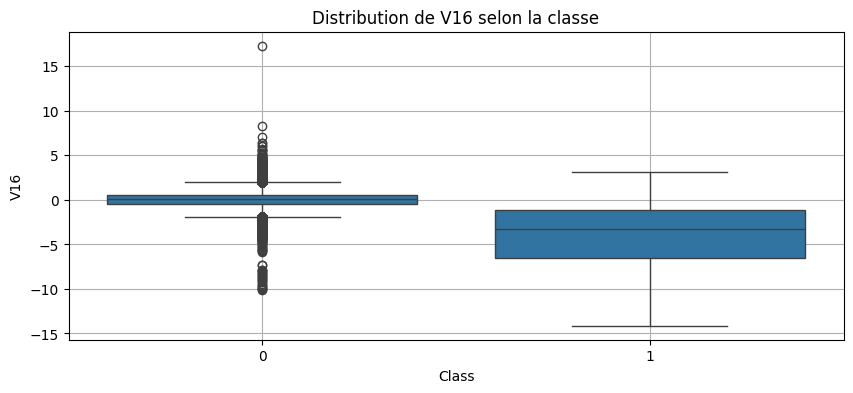

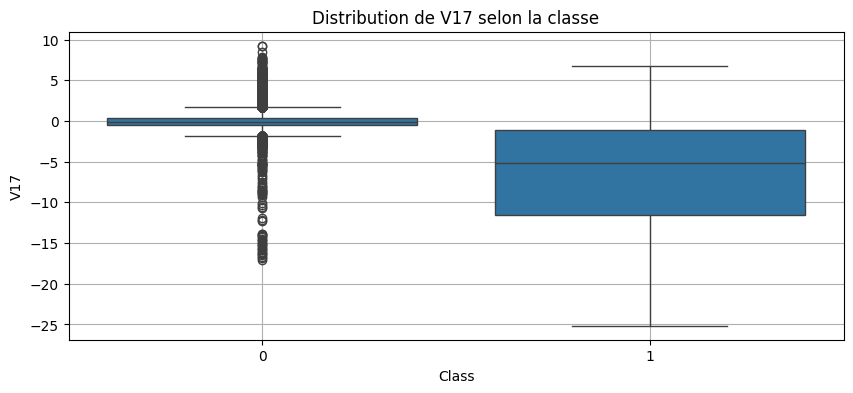

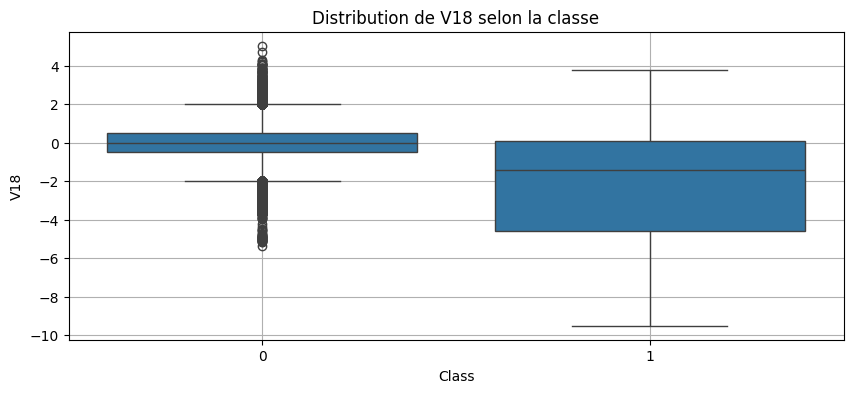

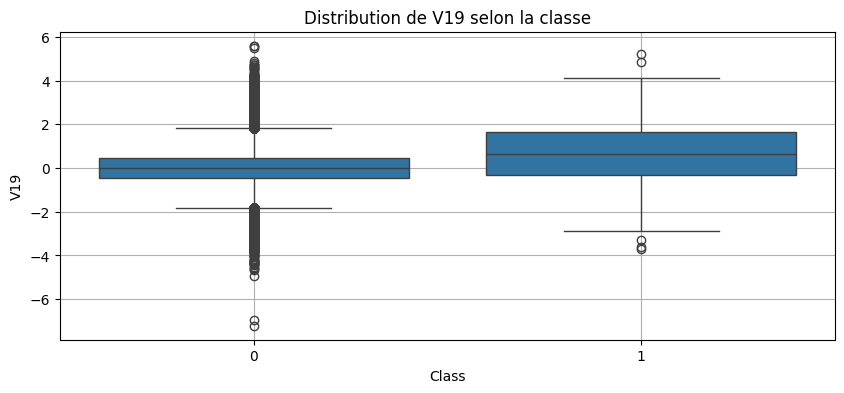

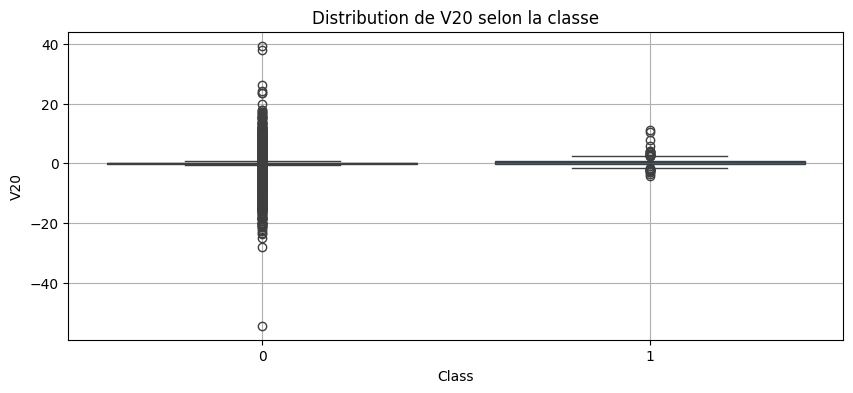

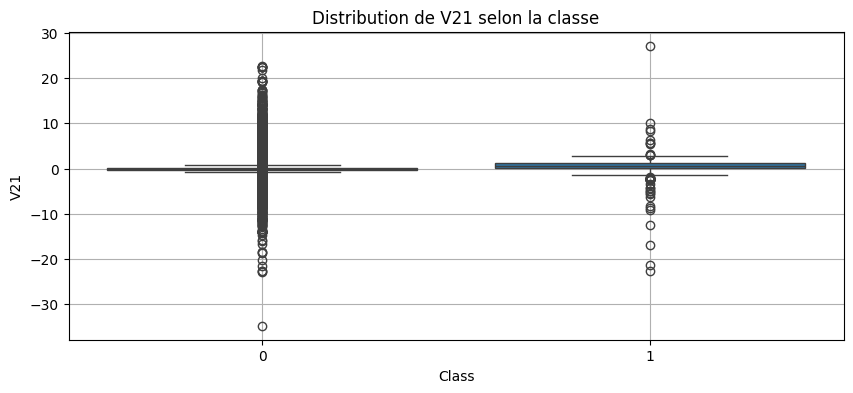

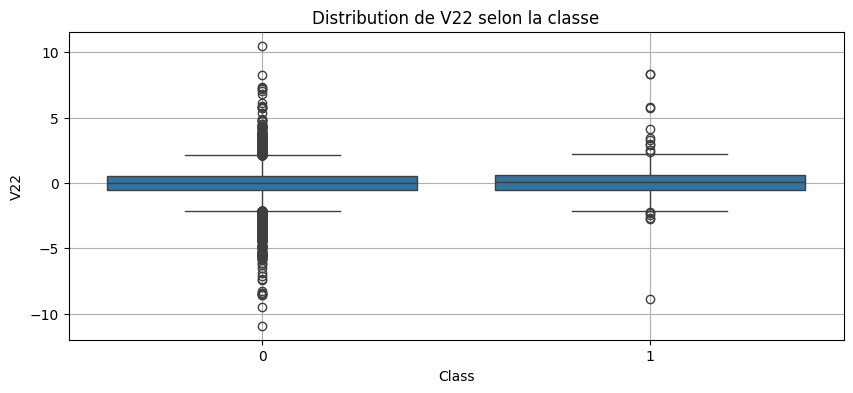

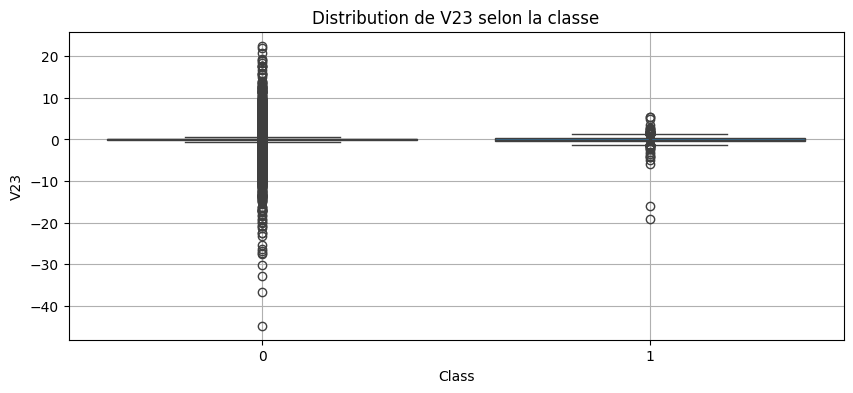

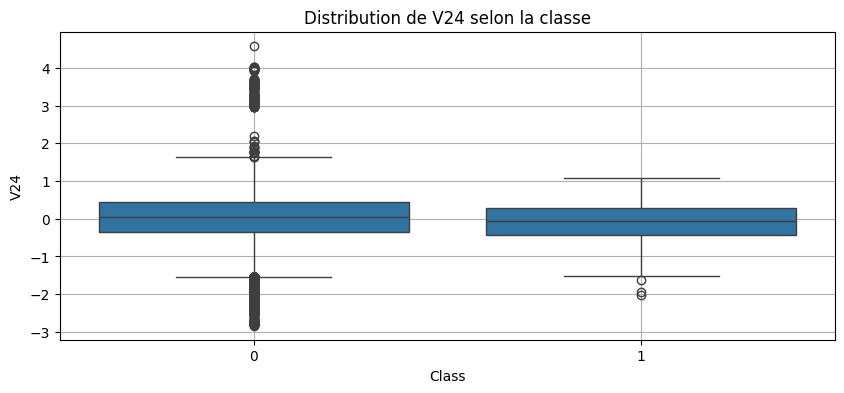

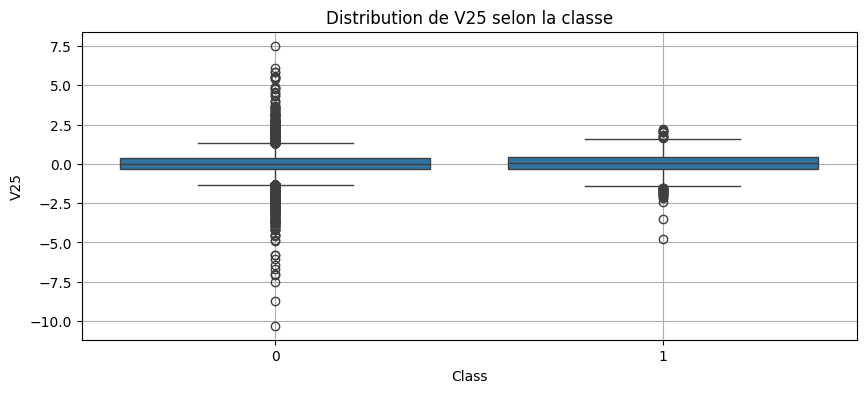

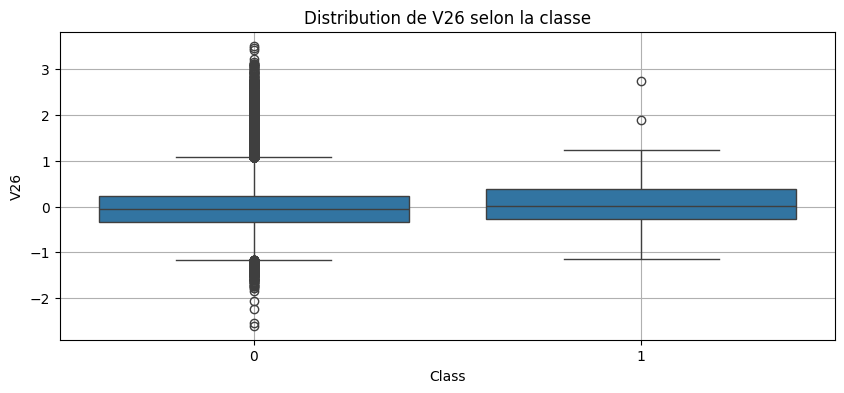

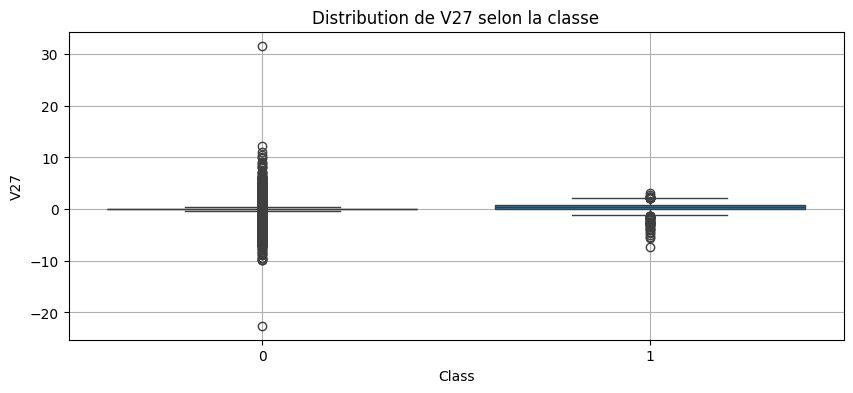

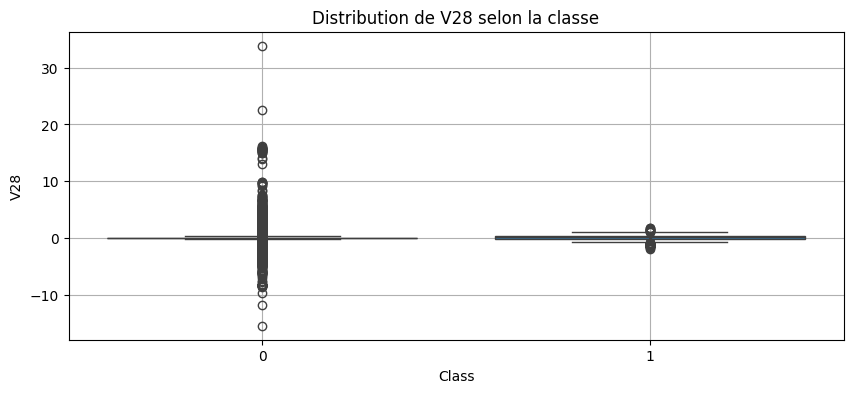

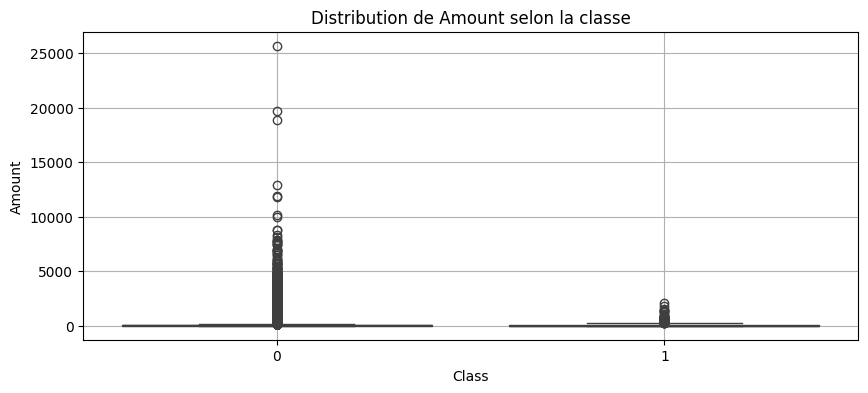

In [ ]:
# Boxplots de quelques variables selon la classe
features = ['V1', 'V2', 'V3','V4', 'V5', 'V6','V7', 'V8', 'V9','V10', 'V11',
            'V12','V13', 'V14', 'V15','V16', 'V17', 'V18','V19', 'V20', 'V21','V22',
            'V23', 'V24','V25', 'V26', 'V27', 'V28','Amount']
for feature in features:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='Class', y=feature, data=df)
    plt.title(f"Distribution de {feature} selon la classe")
    plt.grid(True)
    plt.show()

In [ ]:
#Maintenant comme V1 à V28 provient du PCA il est déjà standardisé
#Il faut juste standardié "Amount", "Time"

#Objectif de la standardisation :
#Moyenne = 0
#Écart-type = 1

#Différence fondamentale entre standardiser et normaliser
#Opération	Objectif	                    Résultat typique
#Standardisation	Centrer (moyenne = 0),        réduire (écart-type = 1)	Garde la forme de la distribution
#Normalisation	Mettre dans un intervalle fixe (souvent [0, 1])	      Écrase les valeurs dans une même échelle

#print("Avant",df[['Amount', 'Time']].describe())
#print(df['Amount'].describe())
#scaler = StandardScaler()
#df[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])


#print("Après",df[['Amount', 'Time']].describe())

#### Vérification de la standardisation de `Amount` et `Time`

#Avant toute transformation, nous avons constaté que :
#- La **moyenne** de `Amount` et `Time` est proche de 0 (`≈ 0.0`)
#- L’**écart-type** est proche de 1 (`≈ 1.0`)
#- Les **quartiles** et la **forme de la distribution** sont compatibles avec une standardisation préalable
#Cela confirme que **ces variables ont déjà été standardisées** dans le dataset d’origine (`creditcard.csv`)

#**Aucune transformation supplémentaire n’est nécessaire au final.**

Avant              Amount          Time
count  2.837260e+05  2.837260e+05
mean  -6.010385e-18 -6.411078e-18
std    1.000002e+00  1.000002e+00
min   -3.533268e-01 -1.996823e+00
25%   -3.309625e-01 -8.552128e-01
50%   -2.654671e-01 -2.131081e-01
75%   -4.378088e-02  9.369423e-01
max    1.022476e+02  1.642362e+00
count    2.837260e+05
mean    -6.010385e-18
std      1.000002e+00
min     -3.533268e-01
25%     -3.309625e-01
50%     -2.654671e-01
75%     -4.378088e-02
max      1.022476e+02
Name: Amount, dtype: float64
Après              Amount          Time
count  2.837260e+05  2.837260e+05
mean  -4.407616e-18 -6.411078e-18
std    1.000002e+00  1.000002e+00
min   -3.533268e-01 -1.996823e+00
25%   -3.309625e-01 -8.552128e-01
50%   -2.654671e-01 -2.131081e-01
75%   -4.378088e-02  9.369423e-01
max    1.022476e+02  1.642362e+00


In [ ]:
from sklearn.model_selection import train_test_split

# Définir X et y
X = df.drop('Class', axis=1)  # toutes les colonnes sauf la cible
y = df['Class']               # la cible à prédire

# Split train/test (80% train, 20% test) en stratifiant selon la classe
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Afficher les tailles
print(f"Taille du jeu d'entraînement : {X_train.shape}")
print(f"Taille du jeu de test        : {X_test.shape}")

# Vérifier la répartition des classes dans chaque set
print("\nRépartition dans le jeu d'entraînement :")
print(y_train.value_counts(normalize=True))

print("\nRépartition dans le jeu de test :")
print(y_test.value_counts(normalize=True))


Taille du jeu d'entraînement : (226980, 30)
Taille du jeu de test        : (56746, 30)

Répartition dans le jeu d'entraînement :
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64

Répartition dans le jeu de test :
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

# Modèle avec pondération automatique
model_weighted = RandomForestClassifier(class_weight='balanced', random_state=42)
model_weighted.fit(X_train, y_train)

# Prédictions
y_pred_weighted = model_weighted.predict(X_test)
y_proba_weighted = model_weighted.predict_proba(X_test)[:, 1]

# Affichage des métriques
print("🔷 Modèle A — RandomForest avec class_weight='balanced'")
print("-" * 60)
print(classification_report(y_test, y_pred_weighted, digits=4))
print(f"Recall      : {recall_score(y_test, y_pred_weighted):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_weighted):.4f}")
print(f"F1-score    : {f1_score(y_test, y_pred_weighted):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_proba_weighted):.4f}")
print("-" * 60)


🔷 Modèle A — RandomForest avec class_weight='balanced'
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9995    0.9999    0.9997     56651
           1     0.9577    0.7158    0.8193        95

    accuracy                         0.9995     56746
   macro avg     0.9786    0.8579    0.9095     56746
weighted avg     0.9995    0.9995    0.9994     56746

Recall      : 0.7158
Precision   : 0.9577
F1-score    : 0.8193
AUC-ROC     : 0.9404
------------------------------------------------------------


In [ ]:
from imblearn.over_sampling import SMOTE
# Rééchantillonnage avec SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Modèle standard (sans class_weight)
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

# Prédictions
y_pred_smote = model_smote.predict(X_test)
y_proba_smote = model_smote.predict_proba(X_test)[:, 1]

# Affichage des métriques
print("🔶 Modèle B — RandomForest avec SMOTE sur X_train")
print("-" * 60)
print(classification_report(y_test, y_pred_smote, digits=4))
print(f"Recall      : {recall_score(y_test, y_pred_smote):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred_smote):.4f}")
print(f"F1-score    : {f1_score(y_test, y_pred_smote):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_proba_smote):.4f}")
print("-" * 60)

🔶 Modèle B — RandomForest avec SMOTE sur X_train
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     56651
           1     0.9114    0.7579    0.8276        95

    accuracy                         0.9995     56746
   macro avg     0.9555    0.8789    0.9137     56746
weighted avg     0.9994    0.9995    0.9994     56746

Recall      : 0.7579
Precision   : 0.9114
F1-score    : 0.8276
AUC-ROC     : 0.9584
------------------------------------------------------------


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

# Entraînement
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)
logreg.fit(X_train, y_train)

#Modèle D — Logistic Regression (class_weight='balanced')
#------------------------------------------------------------
#              precision    recall  f1-score   support

#           0     0.9998    0.9696    0.9844     56651
#           1     0.0459    0.8737    0.0872        95

#    accuracy                         0.9694     56746
#   macro avg     0.5228    0.9216    0.5358     56746
#weighted avg     0.9982    0.9694    0.9829     56746

#Recall      : 87.37 %
#Precision   : 4.59 %
#F1-score    : 8.72 %
#AUC-ROC     : 95.90 %

# Prédictions
y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# Évaluation
print("🔷 Modèle D — Logistic Regression (class_weight='balanced')")
print("-" * 60)
print(classification_report(y_test, y_pred_logreg, digits=4))
print(f"Recall      : {recall_score(y_test, y_pred_logreg) * 100:.2f} %")
print(f"Precision   : {precision_score(y_test, y_pred_logreg) * 100:.2f} %")
print(f"F1-score    : {f1_score(y_test, y_pred_logreg) * 100:.2f} %")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_proba_logreg) * 100:.2f} %")
print("-" * 60)


🔷 Modèle D — Logistic Regression (class_weight='balanced')
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9998    0.9696    0.9844     56651
           1     0.0459    0.8737    0.0872        95

    accuracy                         0.9694     56746
   macro avg     0.5228    0.9216    0.5358     56746
weighted avg     0.9982    0.9694    0.9829     56746

Recall      : 87.37 %
Precision   : 4.59 %
F1-score    : 8.72 %
AUC-ROC     : 95.90 %
------------------------------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE

# Rééquilibrage avec SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Entraînement
logreg_sm = LogisticRegression(max_iter=1000, random_state=42)
logreg_sm.fit(X_train_sm, y_train_sm)

# Prédictions
y_pred_logreg_sm = logreg_sm.predict(X_test)
y_proba_logreg_sm = logreg_sm.predict_proba(X_test)[:, 1]

# Évaluation
print("🔷 Modèle D2 — Logistic Regression + SMOTE")
print("-" * 60)
print(classification_report(y_test, y_pred_logreg_sm, digits=4))
print(f"Recall      : {recall_score(y_test, y_pred_logreg_sm) * 100:.2f} %")
print(f"Precision   : {precision_score(y_test, y_pred_logreg_sm) * 100:.2f} %")
print(f"F1-score    : {f1_score(y_test, y_pred_logreg_sm) * 100:.2f} %")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_proba_logreg_sm) * 100:.2f} %")
print("-" * 60)


🔷 Modèle D2 — Logistic Regression + SMOTE
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9998    0.9901    0.9949     56651
           1     0.1264    0.8526    0.2201        95

    accuracy                         0.9899     56746
   macro avg     0.5631    0.9214    0.6075     56746
weighted avg     0.9983    0.9899    0.9936     56746

Recall      : 85.26 %
Precision   : 12.64 %
F1-score    : 22.01 %
AUC-ROC     : 95.85 %
------------------------------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from xgboost import XGBClassifier

# Calcul du ratio négatif/positif pour scale_pos_weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# Entraînement
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

# Prédictions
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Évaluation
print("🔶 Modèle E — XGBoost (scale_pos_weight)")
print("-" * 60)
print(classification_report(y_test, y_pred_xgb, digits=4))
print(f"Recall      : {recall_score(y_test, y_pred_xgb) * 100:.2f} %")
print(f"Precision   : {precision_score(y_test, y_pred_xgb) * 100:.2f} %")
print(f"F1-score    : {f1_score(y_test, y_pred_xgb) * 100:.2f} %")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_proba_xgb) * 100:.2f} %")
print("-" * 60)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:24:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


🔶 Modèle E — XGBoost (scale_pos_weight)
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56651
           1     0.9605    0.7684    0.8538        95

    accuracy                         0.9996     56746
   macro avg     0.9801    0.8842    0.9268     56746
weighted avg     0.9995    0.9996    0.9995     56746

Recall      : 76.84 %
Precision   : 96.05 %
F1-score    : 85.38 %
AUC-ROC     : 97.90 %
------------------------------------------------------------


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE

# Rééquilibrage
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Entraînement (❌ pas de scale_pos_weight car classes équilibrées)
xgb_sm = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_sm.fit(X_train_sm, y_train_sm)

# Prédictions
y_pred_xgb_sm = xgb_sm.predict(X_test)
y_proba_xgb_sm = xgb_sm.predict_proba(X_test)[:, 1]

# Évaluation
print("🔶 Modèle E2 — XGBoost + SMOTE")
print("-" * 60)
print(classification_report(y_test, y_pred_xgb_sm, digits=4))
print(f"Recall      : {recall_score(y_test, y_pred_xgb_sm) * 100:.2f} %")
print(f"Precision   : {precision_score(y_test, y_pred_xgb_sm) * 100:.2f} %")
print(f"F1-score    : {f1_score(y_test, y_pred_xgb_sm) * 100:.2f} %")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_proba_xgb_sm) * 100:.2f} %")
print("-" * 60)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:38:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


🔶 Modèle E2 — XGBoost + SMOTE
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56651
           1     0.8352    0.8000    0.8172        95

    accuracy                         0.9994     56746
   macro avg     0.9174    0.8999    0.9085     56746
weighted avg     0.9994    0.9994    0.9994     56746

Recall      : 80.00 %
Precision   : 83.52 %
F1-score    : 81.72 %
AUC-ROC     : 96.60 %
------------------------------------------------------------
